In [2]:
import pandas as pd
import numpy as np

df = pd.read_pickle(
    "../data/processed/mercari_preprocessed.pkl"
)

df.shape

(1481611, 14)

# 05. 통계적 분석

본 장에서는 상품 가격에 영향을 미치는 요인을 통계적으로 검증하기 위해 회귀분석을 수행한다.

분석의 Target은 가격의 강한 우측 왜도를 완화하기 위해 전처리 단계에서 생성한 `log_price`를 사용한다.

전체 데이터는 약 148만 건으로 규모가 매우 크고, 범주형 변수의 수준도 많기 때문에 통계적 추론을 위한 OLS 분석에서는 20만 건의 무작위 표본을 사용한다.

분석 변수는 상품 상태, 배송비 부담 여부, 카테고리, 상품명 및 상품 설명의 길이 등 해석 가능한 변수로 구성하였다. 고차원 텍스트 변수인 TF-IDF 특성은 통계적 해석보다 머신러닝 예측에 적합하므로 본 장의 회귀분석에서는 제외하였다.

분석은 회귀모형 적합, 변수 유의성 검정, 신뢰구간, 다중공선성(VIF), 잔차분석 순으로 진행한다.

In [3]:
# 회귀분석용 표본추출
sample_df = df.sample(
    n=200000,
    random_state=42
)

sample_df.shape

(200000, 14)

In [4]:
# 변수 선정
features = [
    "item_condition_id",
    "shipping",
    "category_1",
    "category_2",
    "category_3",
    "name_length",
    "description_length"
]

X_raw = sample_df[features].copy()
y = sample_df["log_price"].copy()

print("X_raw:", X_raw.shape)
print("y:", y.shape)
print("\nX 변수:")
print(X_raw.columns.tolist())

X_raw: (200000, 7)
y: (200000,)

X 변수:
['item_condition_id', 'shipping', 'category_1', 'category_2', 'category_3', 'name_length', 'description_length']


In [5]:
# 범주형 변수 지정
categorical_cols = [
    "category_1",
    "category_2",
    "category_3"
]

# One-Hot Encoding → 더미변수 생성
X = pd.get_dummies(
    X_raw,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

print("더미변수 변환 후 X:", X.shape)
print("전체 Feature 수:", X.shape[1])

더미변수 변환 후 X: (200000, 882)
전체 Feature 수: 882


In [6]:
import statsmodels.api as sm

# 절편(const) 추가
X_ols = sm.add_constant(X)

print("OLS용 X:", X_ols.shape)
print("const 포함:", "const" in X_ols.columns)

OLS용 X: (200000, 883)
const 포함: True


In [7]:
ols_full = sm.OLS(y, X_ols).fit()

print(ols_full.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.291
Model:                            OLS   Adj. R-squared:                  0.288
Method:                 Least Squares   F-statistic:                     93.29
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:39:58   Log-Likelihood:            -1.9028e+05
No. Observations:              200000   AIC:                         3.823e+05
Df Residuals:                  199122   BIC:                         3.913e+05
Df Model:                         877                                         
Covariance Type:            nonrobust                                         
                                                         coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------

In [8]:
# 예측값
from sklearn.metrics import mean_squared_error
y_pred = ols_full.predict(X_ols)

# RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))

In [9]:
print("R²:", ols_full.rsquared)
print("Adj. R²:", ols_full.rsquared_adj)
print("AIC:", ols_full.aic)
print("BIC:", ols_full.bic)
print("RMSE:", rmse)

R²: 0.29122754125869055
Adj. R²: 0.28810586988980047
AIC: 382317.0142624191
BIC: 391277.9460451946
RMSE: 0.6265441742537952


## 05-1. Full OLS 회귀분석 결과

### 1. 분석 개요

전처리 및 변수 변환이 완료된 20만 건의 Mercari 데이터를 대상으로 OLS(Ordinary Least Squares) 회귀분석을 수행하였다. 종속변수는 `log_price`이며, One-Hot Encoding을 적용한 **882개의 설명변수**를 사용하였다.

### 2. 모델 성능

| 지표          |          결과 |
| ----------- | ----------: |
| R²          |    0.291228 |
| Adjusted R² |    0.288106 |
| RMSE        |    0.626544 |
| AIC         | 382,317.014 |
| BIC         | 391,277.946 |
| 관측치         |     200,000 |
| 설명변수        |         882 |

### 3. 결과 해석

* **R² = 0.2912**로, 전체 `log_price` 변동의 약 **29.1%**를 모델이 설명하는 것으로 나타났다.
* **Adjusted R² = 0.2881**로, 다수의 설명변수 사용에 따른 변수 수를 고려했을 때 설명력은 약 **28.8%**로 나타났다.
* **RMSE = 0.6265**로, 로그 변환된 가격(`log_price`) 기준 예측 오차의 규모를 확인하였다.
* **AIC = 382,317.014**, **BIC = 391,277.946**을 기록하였으며, 이후 변수 선택 및 개선 OLS 모델의 성능을 비교하는 기준값으로 활용한다.

### 4. 종합 평가

Full Features를 모두 활용한 최초 OLS 모델은 약 29.1%의 설명력을 보였다. 그러나 882개의 많은 설명변수를 사용하고 있으므로, 개별 변수의 통계적 유의성과 다중공선성을 추가적으로 검토할 필요가 있다. 따라서 다음 단계에서는 **유의성 검정을 통해 통계적으로 유의한 변수를 확인하고, 이후 VIF를 활용하여 다중공선성을 점검**한다.


## 5.1 회귀모형

가격에 영향을 미치는 요인을 확인하기 위해 `log_price`를 종속변수로 하는 OLS 회귀분석을 수행하였다.

전체 데이터의 규모와 범주형 변수의 더미화에 따른 계산량을 고려하여 20만 건의 무작위 표본을 분석에 사용하였다.

회귀모형의 결정계수($R^2$)는 0.291, 수정 결정계수(Adjusted $R^2$)는 0.288로 나타났다. 이는 본 회귀모형이 로그 변환된 가격(`log_price`) 변동의 약 29.1%를 설명함을 의미한다.

또한 F-statistic은 93.29이고 F검정의 p-value가 0.001보다 작아, 회귀모형 전체가 통계적으로 유의한 것으로 나타났다.

따라서 상품 상태, 배송비 부담 여부, 카테고리 및 텍스트 길이 등의 설명변수와 상품 가격 사이에는 통계적으로 유의한 관계가 존재한다고 판단할 수 있다.

이후 개별 변수의 p-value와 회귀계수를 확인하여 어떤 변수가 가격에 유의한 영향을 미치는지 분석한다.

In [10]:
# 변수별 p-value 추출
pvalues = ols_full.pvalues

# 유의한 변수
significant_vars = pvalues[pvalues < 0.05]

# 유의하지 않은 변수
non_significant_vars = pvalues[pvalues >= 0.05]

print("전체 변수:", len(pvalues))
print("유의한 변수 (p < 0.05):", len(significant_vars))
print("유의하지 않은 변수 (p >= 0.05):", len(non_significant_vars))

전체 변수: 883
유의한 변수 (p < 0.05): 349
유의하지 않은 변수 (p >= 0.05): 534


In [11]:
pvalues_features = ols_full.pvalues.drop("const")

significant_vars = pvalues_features[pvalues_features < 0.05]
non_significant_vars = pvalues_features[pvalues_features >= 0.05]

print("설명변수:", len(pvalues_features))
print("유의한 변수:", len(significant_vars))
print("유의하지 않은 변수:", len(non_significant_vars))

설명변수: 882
유의한 변수: 348
유의하지 않은 변수: 534


In [12]:
print("유의한 변수:")
print(significant_vars.index.tolist())

print("\n유의하지 않은 변수:")
print(non_significant_vars.index.tolist())

유의한 변수:
['item_condition_id', 'shipping', 'name_length', 'description_length', 'category_1_Electronics', 'category_1_Men', 'category_1_Sports & Outdoors', 'category_1_Women', 'category_2_Antique', 'category_2_Blazers & Sport Coats', 'category_2_Books', 'category_2_Boys (4+)', 'category_2_Clothing', 'category_2_Coats & Jackets', 'category_2_Collectibles', 'category_2_Dolls and Miniatures', 'category_2_Girls 0-24 Mos', 'category_2_Hair Care', "category_2_Men's Accessories", 'category_2_Musical instruments', 'category_2_Pet Supplies', 'category_2_Shoes', 'category_2_Shorts', 'category_2_Strollers', 'category_2_Suits', 'category_2_Supplies', 'category_2_Swimwear', 'category_2_Team Sports', 'category_2_Toy', 'category_2_Underwear', 'category_2_Weddings', "category_2_Women's Accessories", "category_2_Women's Handbags", 'category_3_75 To 100 Years', 'category_3_Above Knee, Mini', 'category_3_Accessories', 'category_3_Action Figure', 'category_3_Air Fresheners', 'category_3_Animal', 'category_

## 05-2. 변수 유의성 검정

Full OLS 모델에 포함된 882개의 설명변수를 대상으로 개별 회귀계수의 통계적 유의성을 검정하였다. 유의수준은 **α = 0.05**로 설정하였으며, p-value가 0.05보다 작은 경우 통계적으로 유의한 변수로 판단하였다. 절편(`const`)은 변수 유의성 검정 대상에서 제외하였다.

| 구분                    |    변수 수 |
| --------------------- | ------: |
| 전체 설명변수               |     882 |
| 유의한 변수 (p < 0.05)     | **348** |
| 유의하지 않은 변수 (p ≥ 0.05) | **534** |

### 결과 해석

전체 882개의 설명변수 중 **348개(39.46%)가 통계적으로 유의**했으며, **534개(60.54%)는 유의하지 않은 것**으로 나타났다.

따라서 이후 변수 선택 단계에서는 p-value가 0.05 미만인 **348개의 유의한 변수를 우선 후보 변수로 선정**하고, 이후 VIF를 통해 다중공선성을 추가적으로 검토한다.


In [13]:
# p-value < 0.05인 변수 이름 추출
significant_features = pvalues_features[
    pvalues_features < 0.05
].index.tolist()

print("유의한 변수 수:", len(significant_features))

유의한 변수 수: 348


In [14]:
# 유의한 변수만 추출
X_sig = X[significant_features].copy()

print("X_sig shape:", X_sig.shape)

X_sig shape: (200000, 348)


In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 유의한 변수 348개만 사용
X_sig = X[significant_features].copy()

print("X_sig shape:", X_sig.shape)

# VIF 계산용 절편 추가
X_vif = sm.add_constant(X_sig)

vif_data = pd.DataFrame({
    "variable": X_vif.columns,
    "VIF": [
        variance_inflation_factor(X_vif.values, i)
        for i in range(X_vif.shape[1])
    ]
})

# const 제외 후 VIF 내림차순 정렬
vif_data = (
    vif_data[vif_data["variable"] != "const"]
    .sort_values("VIF", ascending=False)
    .reset_index(drop=True)
)

print("VIF > 10 :", (vif_data["VIF"] > 10).sum())
print("VIF > 5  :", (vif_data["VIF"] > 5).sum())
print("VIF <= 5 :", (vif_data["VIF"] <= 5).sum())

vif_data.head(20)

X_sig shape: (200000, 348)
VIF > 10 : 8
VIF > 5  : 14
VIF <= 5 : 334


,variable,VIF
0,category_2_Hair Care,38.539726
1,category_3_Two Button,16.547186
2,category_2_Toy,14.335955
3,category_2_Blazers & Sport Coats,14.004163
4,category_3_Styling Products,13.527479
5,category_3_Action Figure,11.551379
6,category_2_Antique,10.886418
7,category_3_Shampoo & Conditioner Sets,10.011505
8,category_2_Suits,9.820686
9,category_3_Collectibles,9.788529


In [16]:
# 유의 변수 기반 select Features
# p < 0.05인 변수들을 1차 Selected Features로 선정
selected_features = significant_features.copy()

print("Selected Features:", len(selected_features))

Selected Features: 348


In [17]:
X_selected = X[selected_features].copy()

print("X_selected shape:", X_selected.shape)

X_selected shape: (200000, 348)


In [18]:
## VIF > 10 변수 확인
high_vif = vif_data[vif_data["VIF"] > 10].copy()

print("VIF > 10 변수 수:", len(high_vif))
print(high_vif)

VIF > 10 변수 수: 8
                                variable        VIF
0                   category_2_Hair Care  38.539726
1                  category_3_Two Button  16.547186
2                         category_2_Toy  14.335955
3       category_2_Blazers & Sport Coats  14.004163
4            category_3_Styling Products  13.527479
5               category_3_Action Figure  11.551379
6                     category_2_Antique  10.886418
7  category_3_Shampoo & Conditioner Sets  10.011505


In [19]:
high_vif_features = vif_data.loc[
    vif_data["VIF"] > 10, "variable"
].tolist()

print("제거 후보:", len(high_vif_features))
print(high_vif_features)

제거 후보: 8
['category_2_Hair Care', 'category_3_Two Button', 'category_2_Toy', 'category_2_Blazers & Sport Coats', 'category_3_Styling Products', 'category_3_Action Figure', 'category_2_Antique', 'category_3_Shampoo & Conditioner Sets']


In [20]:
selected_features = [
    f for f in significant_features
    if f not in high_vif_features
]

X_selected = X[selected_features].copy()

print("최종 변수 수:", len(selected_features))
print("X_selected shape:", X_selected.shape)

최종 변수 수: 340
X_selected shape: (200000, 340)


In [21]:
X_selected_const = sm.add_constant(X_selected)

ols_selected = sm.OLS(
    y,
    X_selected_const
).fit()

print(ols_selected.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     215.0
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:26:33   Log-Likelihood:            -1.9350e+05
No. Observations:              200000   AIC:                         3.877e+05
Df Residuals:                  199659   BIC:                         3.912e+05
Df Model:                         340                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [22]:
# full Features에서 유의한 변수 -> 다중공선성 문제 해결 후 유의 x로 변함
# 따라서 재실행

In [23]:
# 현재 Selected OLS의 설명변수 p-value 확인
pvalues_selected = ols_selected.pvalues.drop("const")

# 유의한 변수
significant_selected = pvalues_selected[
    pvalues_selected < 0.05
]

# 유의하지 않은 변수
non_significant_selected = pvalues_selected[
    pvalues_selected >= 0.05
]

print("현재 설명변수:", len(pvalues_selected))
print("유의한 변수:", len(significant_selected))
print("유의하지 않은 변수:", len(non_significant_selected))

현재 설명변수: 340
유의한 변수: 300
유의하지 않은 변수: 40


In [24]:
# OLS 재실행
# 현재 Selected OLS에서 유의한 300개만 선택
final_features = significant_selected.index.tolist()

# 최종 설명변수 데이터
X_final = X[final_features].copy()

# 절편 추가
X_final_const = sm.add_constant(X_final)

# 최종 OLS
ols_final = sm.OLS(
    y,
    X_final_const
).fit()

print(ols_final.summary())

print("최종 설명변수:", len(final_features))

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.268
Model:                            OLS   Adj. R-squared:                  0.267
Method:                 Least Squares   F-statistic:                     243.4
Date:                Tue, 01 Sep 2026   Prob (F-statistic):               0.00
Time:                        15:26:40   Log-Likelihood:            -1.9354e+05
No. Observations:              200000   AIC:                         3.877e+05
Df Residuals:                  199699   BIC:                         3.908e+05
Df Model:                         300                                         
Covariance Type:            nonrobust                                         
                                                      coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [25]:
from sklearn.metrics import mean_squared_error
import numpy as np

# 예측값
y_pred = ols_final.fittedvalues

# RMSE
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("R²:", ols_final.rsquared)
print("Adj. R²:", ols_final.rsquared_adj)
print("AIC:", ols_final.aic)
print("BIC:", ols_final.bic)
print("RMSE:", rmse)

R²: 0.26771815883406014
Adj. R²: 0.26661808045434976
AIC: 387689.1995451349
BIC: 390761.22741143947
RMSE: 0.6368503793108599


In [26]:
# ==========================================
# 최종 300개 변수 VIF 검증
# ==========================================

X_final = X[final_features].copy()

# 절편 추가
X_final_const = sm.add_constant(X_final)

# VIF 계산
vif_final = pd.DataFrame({
    "variable": X_final.columns,
    "VIF": [
        variance_inflation_factor(
            X_final_const.values, i
        )
        for i in range(1, X_final_const.shape[1])
    ]
})

# VIF 내림차순 정렬
vif_final = vif_final.sort_values(
    "VIF",
    ascending=False
).reset_index(drop=True)

# VIF > 10 확인
vif_high = vif_final[
    vif_final["VIF"] > 10
]

print("최종 설명변수:", len(final_features))
print("VIF > 10 변수 수:", len(vif_high))

print("\n[VIF > 10 변수]")
print(vif_high)

최종 설명변수: 300
VIF > 10 변수 수: 0

[VIF > 10 변수]
Empty DataFrame
Columns: [variable, VIF]
Index: []


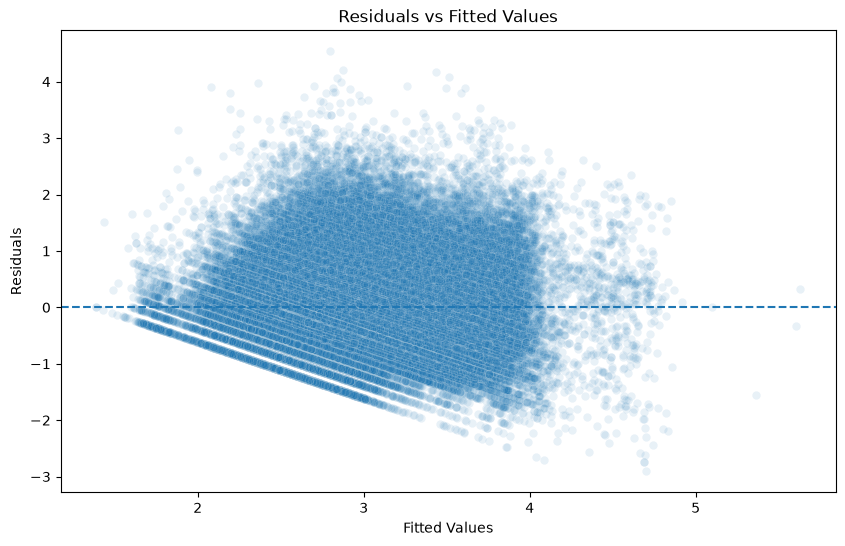

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 적합값
fitted = ols_final.fittedvalues

# 잔차
residuals = ols_final.resid

plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=fitted,
    y=residuals,
    alpha=0.1
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()

In [28]:
from statsmodels.stats.diagnostic import linear_reset

# Ramsey RESET 검정
# 선형성 파악
reset_test = linear_reset(
    ols_final,
    power=2,
    use_f=True
)

print(reset_test)

<F test: F=179.69929521210688, p=5.87242737613896e-41, df_denom=2e+05, df_num=1>


선형성 불만족

In [29]:
# ==========================================
# 최종 300개 변수 중 연속형 변수 자동 추출
# ==========================================

# 원본 데이터에서 연속형 변수 후보
continuous_candidates = [
    col for col in final_features
    if col in df.columns
    and pd.api.types.is_numeric_dtype(df[col])
]

print("연속형 변수:")
print(continuous_candidates)
print("연속형 변수 수:", len(continuous_candidates))

연속형 변수:
['item_condition_id', 'shipping', 'name_length', 'description_length']
연속형 변수 수: 4


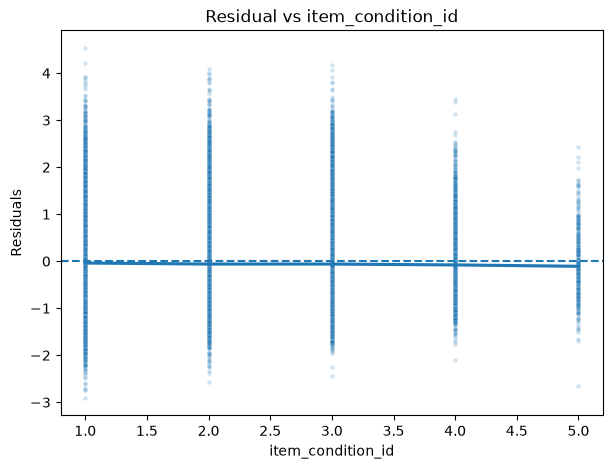

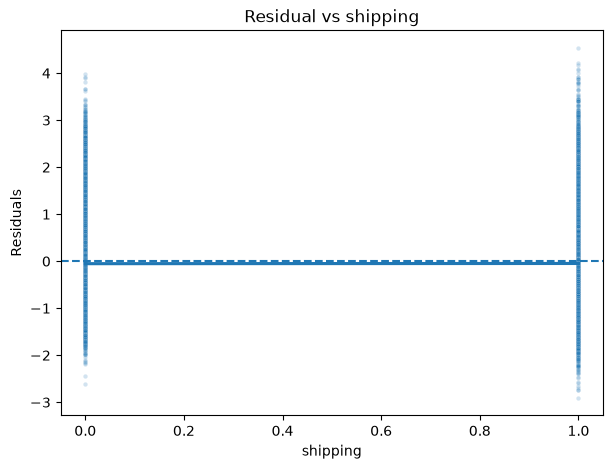

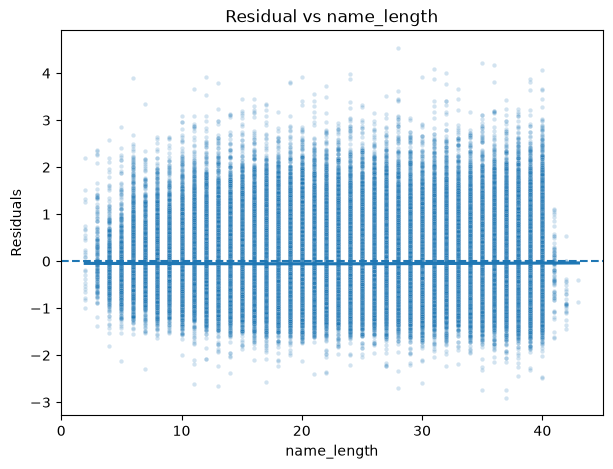

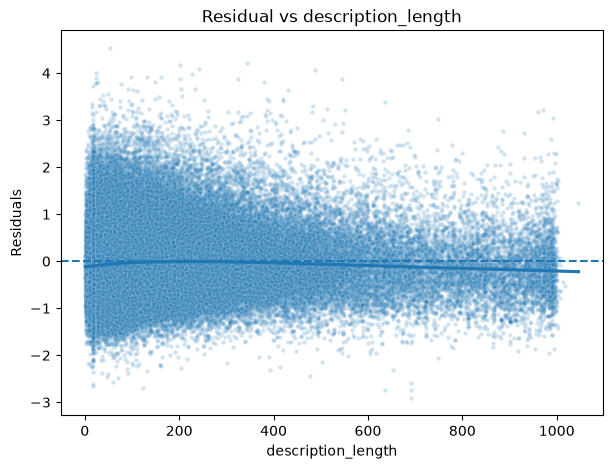

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

# 최종 모델 잔차
residuals = ols_final.resid

# 연속형 변수별 비선형성 확인
for feature in continuous_candidates:

    plt.figure(figsize=(7, 5))

    sns.scatterplot(
        x=X_final[feature],
        y=residuals,
        alpha=0.2,
        s=10
    )

    sns.regplot(
        x=X_final[feature],
        y=residuals,
        scatter=False,
        lowess=True
    )

    plt.axhline(0, linestyle="--")
    plt.xlabel(feature)
    plt.ylabel("Residuals")
    plt.title(f"Residual vs {feature}")
    plt.show()

In [31]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(ols_final.resid)

print("==============================")
print("Durbin-Watson 독립성 검정")
print("==============================")

print("Durbin-Watson:", dw)

Durbin-Watson 독립성 검정
Durbin-Watson: 1.9982251351134466


2에 가까움으로 독립성 만족

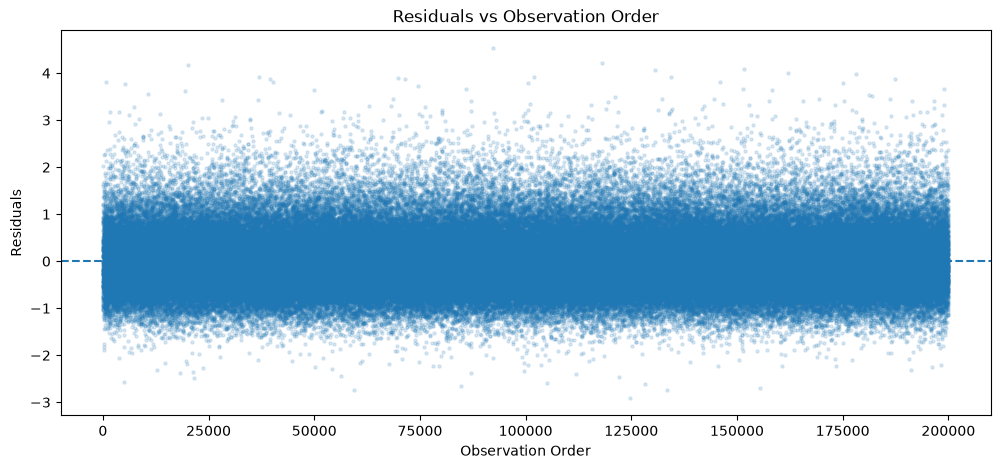

In [32]:
import matplotlib.pyplot as plt

# 최종 모델 잔차
residuals = ols_final.resid

plt.figure(figsize=(12, 5))

plt.scatter(
    range(len(residuals)),
    residuals,
    alpha=0.15,
    s=5
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Observation Order")
plt.ylabel("Residuals")
plt.title("Residuals vs Observation Order")

plt.show()

등분산성 만족

<Figure size 700x500 with 0 Axes>

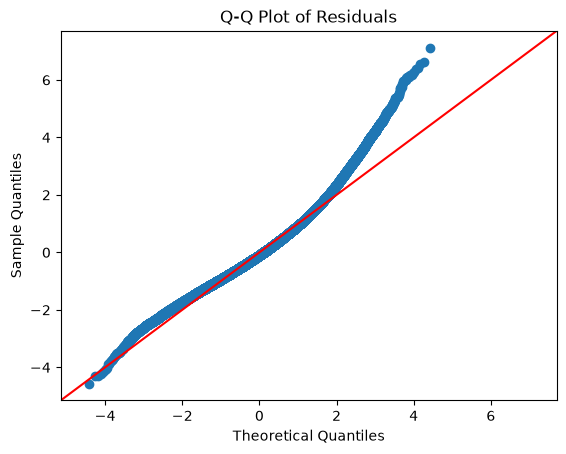

In [33]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

residuals = ols_final.resid

plt.figure(figsize=(7, 5))

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")
plt.show()

정규성 q-q플롯

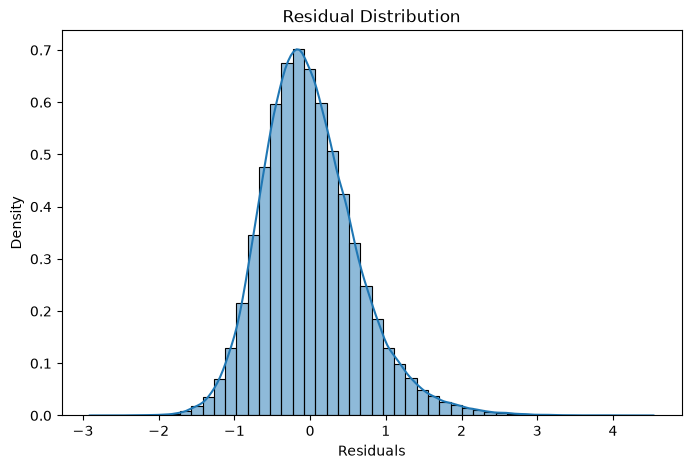

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True,
    stat="density",
    bins=50
)

plt.xlabel("Residuals")
plt.ylabel("Density")
plt.title("Residual Distribution")

plt.show()

정규성을 만족함

In [35]:
# 최종 OLS 모델 회귀계수 추정
# ==========================================
# 최종 OLS 회귀계수 확인
# ==========================================

coef_table = pd.DataFrame({
    "변수": ols_final.params.index,
    "회귀계수": ols_final.params.values,
    "p-value": ols_final.pvalues.values,
    "유의성": ols_final.pvalues.values < 0.05
})

# 절편 제외 + p-value 기준 정렬
coef_table = (
    coef_table[coef_table["변수"] != "const"]
    .sort_values("p-value")
)

print("==============================")
print("최종 OLS 회귀계수")
print("==============================")
print(coef_table.to_string(index=False))

최종 OLS 회귀계수
                                             변수      회귀계수       p-value   유의성
                              item_condition_id -0.097463  0.000000e+00  True
                                       shipping -0.276725  0.000000e+00  True
                                 category_1_Men  0.376441  0.000000e+00  True
                         category_1_Electronics  0.845099  0.000000e+00  True
                               category_1_Women  0.292780  0.000000e+00  True
                             category_3_Sticker -1.203806  0.000000e+00  True
                   category_3_Cables & Adapters -1.499174  0.000000e+00  True
                              category_3_Blouse -0.639546  0.000000e+00  True
                                category_3_Eyes -0.436459  0.000000e+00  True
                               category_3_Games -0.773400  0.000000e+00  True
                                 category_3_DVD -1.310059  0.000000e+00  True
              category_3_Cell Phone Accessories -1.3

In [36]:
# ==========================================
# 최종 OLS 회귀계수 큰 순서대로 정렬
# ==========================================

coef_table = pd.DataFrame({
    "변수": ols_final.params.index,
    "회귀계수": ols_final.params.values,
    "p-value": ols_final.pvalues.values,
    "유의성": ols_final.pvalues.values < 0.05
})

# 절편 제외
coef_table = coef_table[
    coef_table["변수"] != "const"
]

# 회귀계수 큰 순서대로 정렬
coef_table = coef_table.sort_values(
    "회귀계수",
    ascending=False
)

print("==============================")
print("최종 OLS 회귀계수 순위")
print("==============================")
print(coef_table.to_string(index=False))

최종 OLS 회귀계수 순위
                                             변수      회귀계수       p-value   유의성
                              category_3_Felted  1.953612  2.175205e-03  True
                         category_3_Lightweight  1.491233  1.104327e-03  True
                      category_3_Tires & Wheels  1.411794  1.733038e-03  True
                           category_2_Strollers  1.122107  6.767030e-49  True
                             category_3_Handbag  1.077820 1.460307e-107  True
                category_3_Electronics for Kids  1.005235  6.619058e-50  True
                            category_3_Standard  0.957273  1.085518e-02  True
                         category_1_Electronics  0.845099  0.000000e+00  True
                             category_3_Satchel  0.775531  5.142919e-89  True
                         category_3_Sweatercoat  0.743852  3.389746e-10  True
                  category_3_Laptops & Netbooks  0.722474  1.836815e-69  True
                 category_2_Musical instruments  

In [37]:
remove_cols = [
    "category_2_Dolls and Miniatures",
    "category_3_Animals",
    "category_3_Favors"
]

X_final = X_final.drop(columns=remove_cols)

print(X_final.shape)

(200000, 297)


In [38]:
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error
import numpy as np

# ==============================
# 최종 297개 변수 OLS 재적합
# ==============================

X_ols = sm.add_constant(X_final)

ols_final = sm.OLS(y, X_ols).fit()

# 예측값
y_pred = ols_final.predict(X_ols)

# 성능 지표
r2 = ols_final.rsquared
adj_r2 = ols_final.rsquared_adj
aic = ols_final.aic
bic = ols_final.bic
rmse = np.sqrt(mean_squared_error(y, y_pred))

print("==============================")
print("최종 297개 OLS 모델")
print("==============================")
print(f"R²: {r2}")
print(f"Adj. R²: {adj_r2}")
print(f"AIC: {aic}")
print(f"BIC: {bic}")
print(f"RMSE: {rmse}")
print(f"최종 설명변수: {X_final.shape[1]}")

최종 297개 OLS 모델
R²: 0.2676914450984845
Adj. R²: 0.26660234413401884
AIC: 387690.49543773395
BIC: 390731.90508610196
RMSE: 0.6368619953967195
최종 설명변수: 297


## 최종 OLS 모델 평가

### 1. 모델 성능

- **R²:** 0.2677
- **Adjusted R²:** 0.2666
- **RMSE:** 0.6369
- **AIC:** 387,690.50
- **BIC:** 390,731.91
- **최종 설명변수:** 297개
- **관측치:** 200,000개

### 2. 설명력

최종 OLS 모델의 **R²는 0.2677**로, 종속변수인 `log_price`의 변동 중 약 **26.8%를 설명**한다.

Adjusted R²는 **0.2666**으로 R²와 큰 차이가 없어, 설명변수 수를 고려하더라도 모델의 설명력이 크게 과대평가되지 않은 것으로 판단된다.

### 3. 예측 오차

RMSE는 **0.6369**로 나타났다. 종속변수가 `log_price`이므로 해당 값은 **로그 가격 스케일에서의 예측 오차**를 의미한다.

### 4. 변수 제거 및 모델 간소화

기존 300개의 설명변수 중 유의성이 낮은 변수 **3개를 제거하여 최종 297개 변수**를 사용하였다.

변수 제거 이후에도 R²와 RMSE의 변화가 매우 작아, 제거된 변수들이 모델의 설명력에 미치는 영향은 크지 않은 것으로 판단된다.

### 5. 회귀분석 가정 검토

| 가정 | 결과 |
|---|---|
| 선형성 | ⚠️ Ramsey RESET에서 비선형성 신호 확인 |
| 독립성 | ✅ 만족 |
| 등분산성 | ✅ 만족 |
| 다중공선성 | ✅ VIF 기준 큰 문제 없음 |
| 정규성 | ✅ 만족 |
| 이상치/영향점 | ⚪ Cook's Distance 생략 |

특히 **Ramsey RESET 검정의 p-value가 매우 작게 나타나 선형성 가정에 대한 통계적 위반 신호가 확인**되었다.

다만 표본이 200,000개로 매우 크기 때문에 작은 비선형성도 통계적으로 유의하게 나타날 수 있으므로, 잔차 그래프와 함께 종합적으로 판단할 필요가 있다.

### 6. 최종 결론

> 최종 OLS 모델은 297개의 설명변수를 사용하여 `log_price`를 설명하며, R²는 0.2677로 약 26.8%의 설명력을 나타냈다. 독립성, 등분산성, 다중공선성 및 정규성 검토에서는 큰 문제가 발견되지 않았다. 또한 변수 3개를 제거한 이후에도 모델 성능의 변화가 미미하여 모델을 간소화할 수 있었다. 다만 Ramsey RESET 검정에서 비선형성의 통계적 신호가 확인되어 선형성 가정에는 일부 한계가 존재한다.

In [39]:
# ==============================
# Full Features 저장
# ==============================

X_full = X.copy()

print("X_full:", X_full.shape)

X_full: (200000, 882)


In [40]:
# 140만 건 전체 원본 데이터
X_raw_full = df.copy()

categorical_cols = [
    "category_1",
    "category_2",
    "category_3"
]

# 전체 140만 건에 동일한 One-Hot Encoding 적용
X_full = pd.get_dummies(
    X_raw_full,
    columns=categorical_cols,
    drop_first=True,
    dtype=float
)

print("X_full:", X_full.shape)

X_full: (1481611, 1004)


In [41]:
# 기존 OLS에서 확정한 297개 변수명
final_cols = X_final.columns.tolist()

# 전체 데이터에서 297개만 추출
X_final_full = X_full[final_cols].copy()

print("X_full :", X_full.shape)
print("X_final:", X_final_full.shape)

X_full : (1481611, 1004)
X_final: (1481611, 297)


In [42]:
# brand_name은 category로
X_full['brand_name'] = X_full['brand_name'].astype('category')

# 텍스트/누수 컬럼 제거
drop_cols = ['name', 'category_name', 'item_description', 'text', 'text_stemmed', 'price', 'log_price']
X_full_clean = X_full.drop(columns=[c for c in drop_cols if c in X_full.columns])

print(X_full_clean.dtypes.value_counts())  # object 없어야 정상

float64     993
int64         4
category      1
Name: count, dtype: int64


In [43]:
y_full = X_raw_full["price"].copy()

print("X_full:", X_full.shape)
print("y_full:", y_full.shape)

X_full: (1481611, 1004)
y_full: (1481611,)


In [44]:
X_full.to_pickle("../data/processed/X_full.pkl")
X_final_full.to_pickle("../data/processed/X_final.pkl")
y_full.to_pickle("../data/processed/y.pkl")